# Cubic Formula → FIC Tuning

경험 FC 에서 **3차 다항식**으로 엣지별 `wLRE` 를 배정하고 `wFFI = max(0, 2 - wLRE)` 로
유도한 뒤, 그 위에서 **원본 FIC** (`part1_fic.run_fic`) 로 노드별 `c_ei` 를 조절해
`mean_S_e → 0.25` 를 맞춘다.

```
Cell 1 파라미터  →  Cell 2 LOO 3차 계수  →  Cell 3 데이터/네트워크
     →  Cell 4 엣지 가중치 배정 + 행렬 확인  →  Cell 5 FIC (원본 로그)
     →  Cell 6 노드별 c_ei + mean_S_e  →  Cell 7 최종 FC / corr / rmse
```

셀 순서대로 실행한다. 파라미터는 **Cell 1 에서만** 바꾼다.

In [1]:
# JAX 메모리 설정: import 전에 반드시 실행해야 한다
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")

import jax
jax.config.update("jax_enable_x64", False)

import numpy as np
import matplotlib.pyplot as plt

# ⚠ main_ppmi_pd 는 import 시점에 matplotlib 을 Agg 로 바꾸고 plt.show 를
#   "열린 figure 전부 PNG 저장" 으로 덮어쓴다(스크립트 실행용 패치).
#   아래 두 줄로 노트북 inline 표시를 되돌린다. 순서 바꾸지 말 것.
import main_ppmi_pd as M
from data_loader        import load_data
from model              import build_network
from part1_fic          import run_fic
from part3_gradient     import compute_simulated_fc
from pipeline_contracts import (ParamSet, StateBundle, capture_internal_state,
                                capture_network_delay_history)
from formula_cubic      import loo_cubic, WMAX_FIT, BASE_LIN, OPT
from formula_reproduce  import SUBDIR
from formula_2x2        import measure_se

if hasattr(plt, "_main_original_show"):
    plt.show = plt._main_original_show      # 파일저장 패치 해제
try:
    get_ipython().run_line_magic("matplotlib", "inline")   # Agg -> inline 복구
except NameError:
    pass                                    # 스크립트로 실행 중이면 그대로 둔다

print(f"backend : {jax.default_backend()}")
print(f"devices : {jax.devices()}")
print(f"mpl     : {plt.get_backend()}")

backend : gpu
devices : [CudaDevice(id=0)]
jax_enable_x64 : False
backend : gpu
devices : [CudaDevice(id=0)]
mpl     : inline


## Cell 1 — 파라미터

**수정은 이 셀에서만.**

- `MODEL` — `hinge3` 는 clip 을 손실에 넣고 LM 으로 적합(고 FC 에서 되돌아옴 없음),
  `cubic` 은 순수 `polyfit(deg=3)`.
- `NOISE` — **0.02 고정.** `additive_noise_sigma` 는 `cache_tag` 에 없어서 0.01 로 돌리면
  캐시는 정상 매칭되고 시뮬만 절반 노이즈로 돌아 corr 이 조용히 무너진다.

In [2]:
IDX       = 4          # subject index (grad 캐시 보유: 4~8)
MODEL     = "hinge3"   # "hinge3" | "cubic"
NOISE     = 0.02       # ⚠ 0.02 고정
FIC_STEPS = 2000
FIC_TOPK  = 10
USE_DELAY = True

SUB = SUBDIR[IDX]
print(f"idx {IDX} -> subject {SUB}   model={MODEL}   noise={NOISE}   "
      f"fic_steps={FIC_STEPS}  top_k={FIC_TOPK}")

idx 4 -> subject 100878   model=hinge3   noise=0.02   fic_steps=2000  top_k=10


## Cell 2 — LOO 3차 계수 적합 (wLRE 만)

본인을 제외한 subject 들의 optimized `wLRE` 를 SC>0 엣지에서 모아
`wLRE = f(FC_emp)` 를 3차로 적합한다. 본인 데이터는 안 쓰므로 leave-one-out.

`wFFI` 는 **적합하지 않는다** — `wFFI = max(0, 2 - wLRE)` 로 유도한다.
즉 `wLRE <= 2` 인 엣지에서 총 가중치 `wLRE + wFFI` 가 2 로 고정된다.

LOO(hinge3)  적합에 쓴 subject: ['100889', '100905', '100952', '101025', '101038']
  wLRE = +0.9689 +2.8375*FC -0.2820*FC^2 +0.6868*FC^3
  wFFI = max(0, 2 - wLRE)   (적합 안 함)


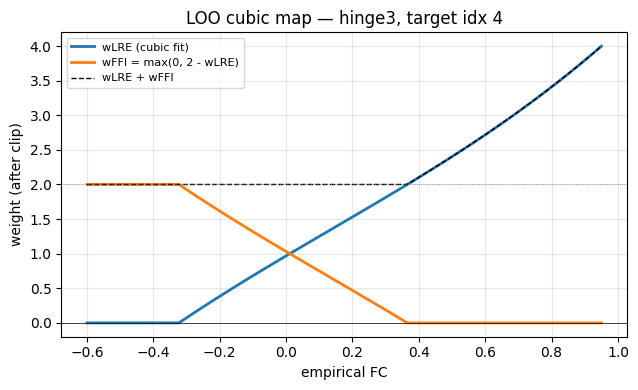

In [3]:
coef_lre, _coef_ffi_unused, used = loo_cubic(SUB, MODEL)

print(f"LOO({MODEL})  적합에 쓴 subject: {used}")
print(f"  wLRE = {coef_lre[3]:+.4f} {coef_lre[2]:+.4f}*FC "
      f"{coef_lre[1]:+.4f}*FC^2 {coef_lre[0]:+.4f}*FC^3")
print(f"  wFFI = max(0, 2 - wLRE)   (적합 안 함)")

xg    = np.linspace(-0.6, 0.95, 400)
wl_g  = np.clip(np.polyval(coef_lre, xg), 0, WMAX_FIT)
wf_g  = np.maximum(0.0, 2.0 - wl_g)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(xg, wl_g,         lw=2, label="wLRE (cubic fit)")
ax.plot(xg, wf_g,         lw=2, label="wFFI = max(0, 2 - wLRE)")
ax.plot(xg, wl_g + wf_g, "k--", lw=1, label="wLRE + wFFI")
ax.axhline(2.0, color="gray", lw=0.6, ls=":")
ax.axhline(0.0, color="k", lw=0.5)
ax.set_xlabel("empirical FC")
ax.set_ylabel("weight (after clip)")
ax.set_title(f"LOO cubic map — {MODEL}, target idx {IDX}")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Cell 3 — 데이터 / 네트워크

`.mat` 에서 이 subject 의 FC/SC/length 를 CSV 로 추출하고 워밍업까지 돈다.

Dataset: AALv3 TR_2.5_PD  (subject idx=4/242, sub_num=100878)
  dropped -> []  → 163 - 0 = 163 nodes
  n_nodes=163  cortex=112  subcortex=51
  SC     -> /scratch/home/wog3597/optim/output_ppmi_pd/100878/inputs/weight.csv   (max=28848)
  length -> /scratch/home/wog3597/optim/output_ppmi_pd/100878/inputs/tract_length.csv  (max=249.0mm)
  FC     -> /scratch/home/wog3597/optim/output_ppmi_pd/100878/inputs/FC.csv   (range=[-0.48,0.89])
  labels -> /scratch/home/wog3597/optim/output_ppmi_pd/100878/inputs/region_labels.txt  (src=data/AALv3/AAL163_labels.txt)
  out_dir-> /scratch/home/wog3597/optim/output_ppmi_pd/100878
  DBS targets (0-based) -> {'STN_L': 161, 'STN_R': 162, 'GP_L': 76, 'GP_R': 77}
[DATA] SC norm='log1pm'  노드당 입력 mean=1.80
[DATA] cortex=112  subcortex=51  FC block share ctx/cross/sub=0.5/0.4/0.1
Cache stored here: /scratch/home/wog3597/optim/output_ppmi_pd/100878/cache/v_pdaal163_tr25_s4_delay3_nbhinge3_N163_scd9877b0546_fc7329897119
[DATA] n_nodes=163  SC nonzero=11830
[DATA]

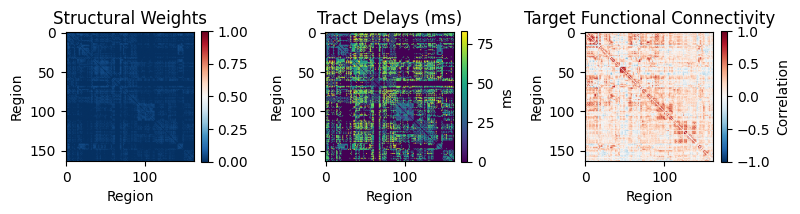

[MODEL] Running warmup simulation...
[MODEL] Warmup done — E mean=0.4731  I mean=0.1720
[MODEL] Graph type: DenseDelayGraph
n_nodes=163   SC>0 엣지 5915 / 13203   w_max=10.0


In [4]:
p   = M.prepare_pd_data(IDX, NOISE)
cfg = M.make_config(p, IDX, use_delay=USE_DELAY)
cfg.cache_version      = f"{cfg.cache_version}_nb{MODEL}"
cfg.fic_max_iterations = FIC_STEPS
cfg.fic_posthoc_top_k  = FIC_TOPK

data = load_data(cfg)
np.fill_diagonal(data["fc_target"], 0.0)
FC_emp = np.nan_to_num(np.asarray(data["fc_target"], np.float32))

network, initial_state, bold_monitor, warmup_result = build_network(cfg, data)

mask, cap, n = data["sc_mask"], cfg.connectivity_weight_max, data["n_nodes"]
sc_bool = mask.astype(bool)
iu = np.triu_indices(n, 1)          # 노드 수에 맞춰 계산 (163 하드코딩 회피)
print(f"n_nodes={n}   SC>0 엣지 {int(sc_bool[iu].sum())} / {len(iu[0])}   w_max={cap}")

## Cell 4 — 엣지 파라미터 배정 + 행렬 확인

`wLRE` 를 먼저 `[0, w_max]` 로 clip 한 **뒤** `wFFI = max(0, 2 - wLRE)` 를 계산한다.
순서가 중요하다 — clip 전 값으로 유도하면 `wLRE < 0` 인 엣지에서 `wFFI > 2` 가 되어
실제 쓰이는 가중치에서 합이 2 가 안 된다.

이어서 `ParamSet.sanitize` 가 `clip[0, w_max] → *sc_mask → 대칭화` 로 투영하므로
SC=0 엣지는 자동으로 0 이 된다.

wLRE: mean 1.446  max 3.747  0 인 SC>0 엣지 0.4%
wFFI: mean 0.623  max 2.000  0 인 SC>0 엣지 16.4%
wLRE+wFFI: wLRE<=2 엣지(83.6%) 에서 합 최대오차 0.00e+00   wLRE>2 엣지 합 범위 2.001~3.747


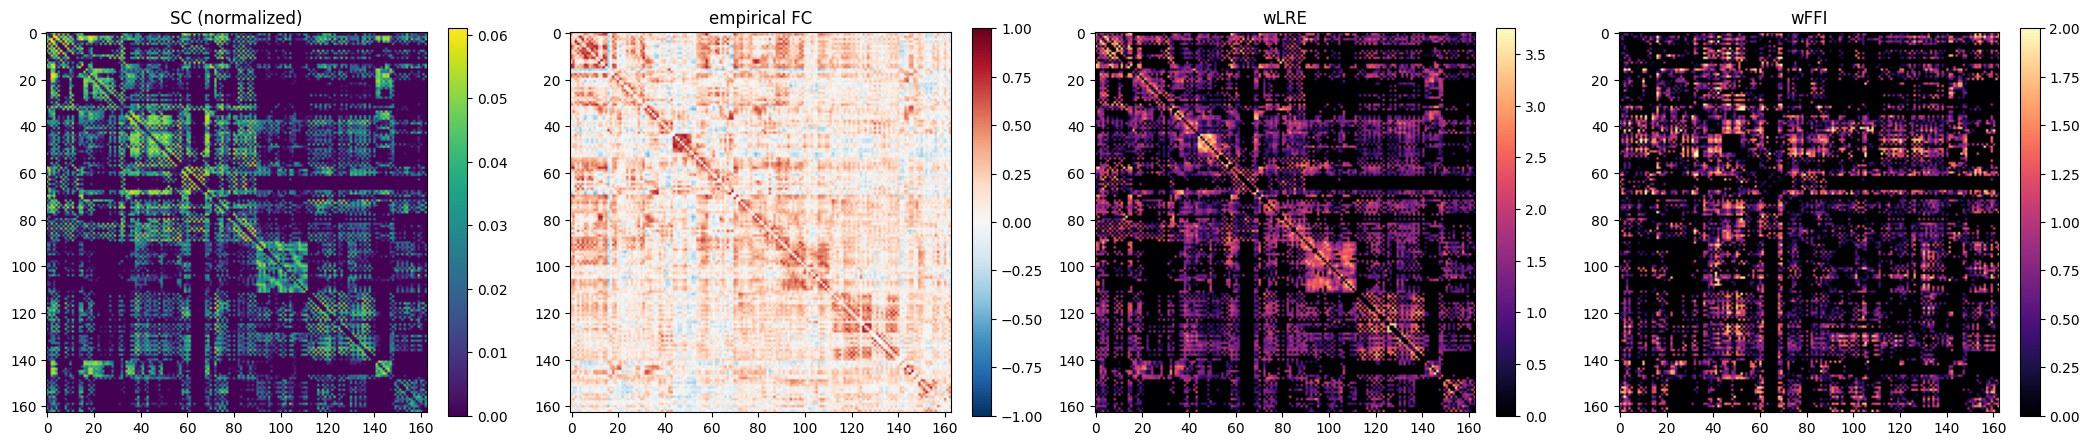

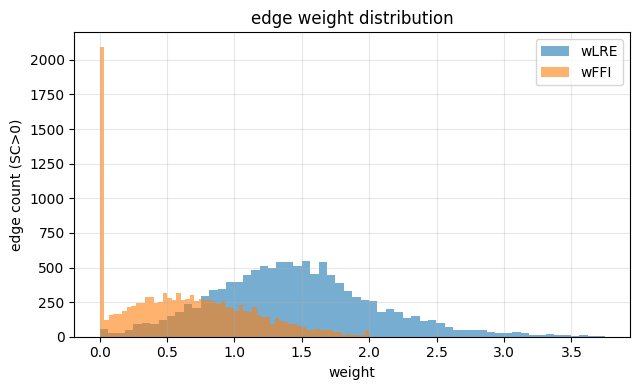

In [5]:
wl = np.clip(np.polyval(coef_lre, FC_emp), 0.0, cap).astype(np.float32)
wf = np.maximum(0.0, 2.0 - wl).astype(np.float32)

params = ParamSet(c_ei=np.ones(n, np.float32), wLRE=wl, wFFI=wf,
                  c_ei_frozen=False).sanitize(mask, cap)
WLRE = np.asarray(params.wLRE)
WFFI = np.asarray(params.wFFI)

for nm, W in (("wLRE", WLRE), ("wFFI", WFFI)):
    v = W[sc_bool]
    print(f"{nm}: mean {v.mean():.3f}  max {v.max():.3f}  "
          f"0 인 SC>0 엣지 {(v <= 1e-6).mean()*100:.1f}%")

# 제약 확인: wLRE <= 2 인 엣지에서 합이 정확히 2 여야 한다.
tot  = (WLRE + WFFI)[sc_bool]
lo   = WLRE[sc_bool] <= 2.0
print(f"wLRE+wFFI: wLRE<=2 엣지({lo.mean()*100:.1f}%) 에서 합 최대오차 "
      f"{np.abs(tot[lo] - 2.0).max():.2e}   wLRE>2 엣지 합 범위 "
      f"{tot[~lo].min() if (~lo).any() else float('nan'):.3f}~"
      f"{tot[~lo].max() if (~lo).any() else float('nan'):.3f}")

panels = [(np.asarray(data["weights"]), "SC (normalized)", "viridis", None),
          (FC_emp,                      "empirical FC",    "RdBu_r", (-1, 1)),
          (WLRE,                        "wLRE",            "magma",  None),
          (WFFI,                        "wFFI",            "magma",  None)]
fig, axes = plt.subplots(1, 4, figsize=(21, 4.8))
for ax, (Mx, ttl, cm, lim) in zip(axes, panels):
    kw = dict(vmin=lim[0], vmax=lim[1]) if lim else {}
    im = ax.imshow(Mx, cmap=cm, aspect="equal", **kw)
    ax.set_title(ttl)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(WLRE[sc_bool], bins=60, alpha=0.6, label="wLRE")
ax.hist(WFFI[sc_bool], bins=60, alpha=0.6, label="wFFI")
ax.set_xlabel("weight"); ax.set_ylabel("edge count (SC>0)")
ax.set_title("edge weight distribution")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Cell 5 — FIC tuning

`part1_fic.run_fic` 를 그대로 호출한다 → 로그는 파이프라인 원본과 동일하다.
`d_c_ei = eta * mean_S_i * (mean_S_e - fic_target_se)`, 노드별.

2000 step 은 GPU 에서 25 분쯤 걸린다.

Running computations for fic_v_pdaal163_tr25_s4_delay3_nbhinge3_N163_scd9877b0546_fc7329897119_se0.25_eta0p5_steps2000_dur2500_skip0_bestbundlev4_fp37023059c4fb
[FIC] target S_e=0.25  eta=0.5  max_steps=2000
  step=2s  skip=0 TR  use=1 TR
  step   25/2000  mean_S_e=0.5407  rE=10.814 Hz  se_err=0.2907  se_ma=inf  (15.4s)
  step   50/2000  mean_S_e=0.2005  rE=4.010 Hz  se_err=0.0495  se_ma=0.2814  (26.1s)
  step   75/2000  mean_S_e=0.1998  rE=3.996 Hz  se_err=0.0502  se_ma=0.0899  (36.7s)
  step  100/2000  mean_S_e=0.3906  rE=7.813 Hz  se_err=0.1406  se_ma=0.0507  (47.7s)
  step  125/2000  mean_S_e=0.2987  rE=5.975 Hz  se_err=0.0487  se_ma=0.0527  (58.3s)
  step  150/2000  mean_S_e=0.4211  rE=8.423 Hz  se_err=0.1711  se_ma=0.0549  (69.1s)
  step  175/2000  mean_S_e=0.2068  rE=4.136 Hz  se_err=0.0432  se_ma=0.0573  (80.1s)
  step  200/2000  mean_S_e=0.2110  rE=4.219 Hz  se_err=0.0390  se_ma=0.0576  (91.0s)
  step  225/2000  mean_S_e=0.2065  rE=4.130 Hz  se_err=0.0435  se_ma=0.0496  (101.8

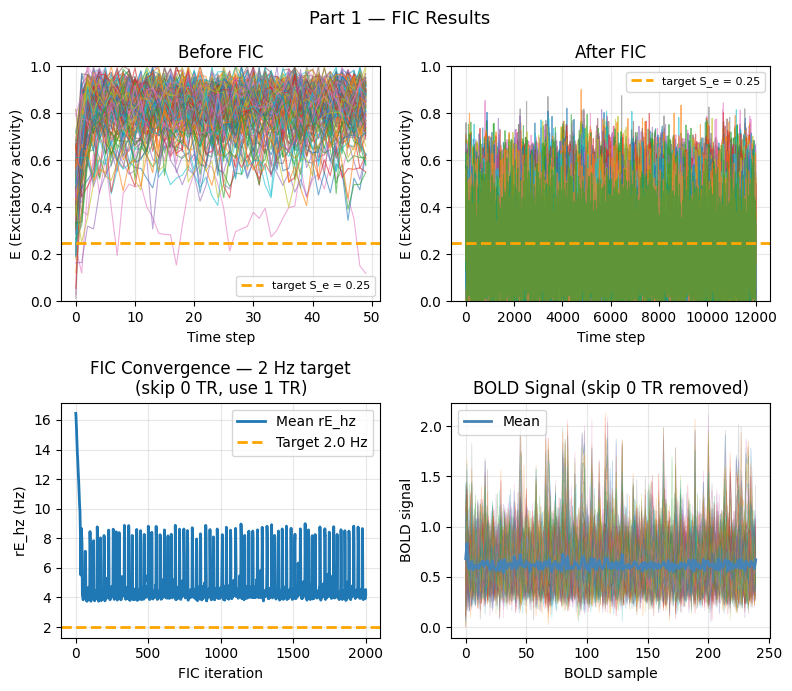

[FIC] FC comparison  Pre-opt corr=0.0254, Pre-opt rmse=0.2475  Post-FIC corr=0.4349, Post-FIC rmse=0.2152


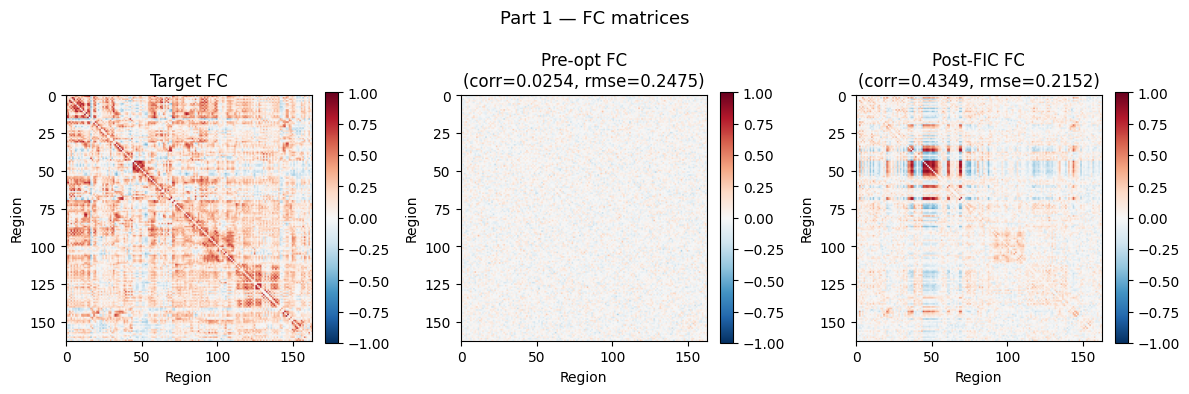

In [6]:
bundle = run_fic(
    network=network,
    cfg=cfg,
    data=data,
    bundle_in=StateBundle.from_warmup(
        warmup_result=warmup_result,
        bold_monitor_template=bold_monitor,
        initial_params=params,
        internal_state=capture_internal_state(initial_state),
        delay_history=capture_network_delay_history(network),
        stage="warmup",
    ),
)

## Cell 6 — 노드별 c_ei 와 mean_S_e

`measure_se` 는 60 초를 돌려 시간·노드 평균 `S_e` 를 낸다.

c_ei     mean 2.0430   범위 1.1125 ~ 3.4686
mean_S_e 0.1940   (target 0.25)   오차 0.0560


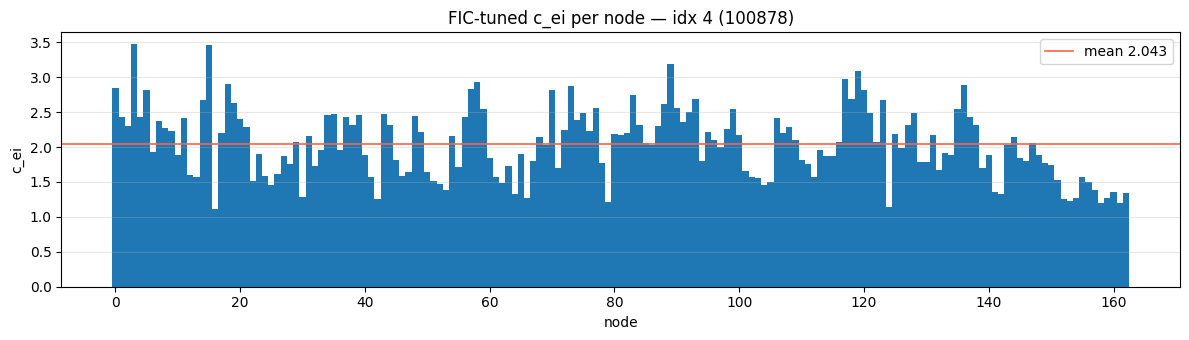

In [7]:
c_ei = np.asarray(bundle.params.c_ei)
se   = measure_se(network, bundle, cfg)

print(f"c_ei     mean {c_ei.mean():.4f}   범위 {c_ei.min():.4f} ~ {c_ei.max():.4f}")
print(f"mean_S_e {se:.4f}   (target {cfg.fic_target_se})   오차 {abs(se-cfg.fic_target_se):.4f}")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(np.arange(n), c_ei, width=1.0)
ax.axhline(c_ei.mean(), color="tomato", lw=1.2, label=f"mean {c_ei.mean():.3f}")
ax.set_xlabel("node"); ax.set_ylabel("c_ei")
ax.set_title(f"FIC-tuned c_ei per node — idx {IDX} ({SUB})")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## Cell 7 — 최종 시뮬레이션 FC / corr / rmse

`optimizer_bold_window_tr × TR` (= 600 초) 를 돌려 FC 를 뽑고 경험 FC 와 비교한다.

idx 4 (100878)   model=hinge3
  corr        +0.4348
  rmse        0.2158
  corr (SC>0) +0.5582
  c_ei mean   2.0430      mean_S_e 0.1940
  참고: 선형공식 0.6497   optimized 0.7515   재현율 57.9%


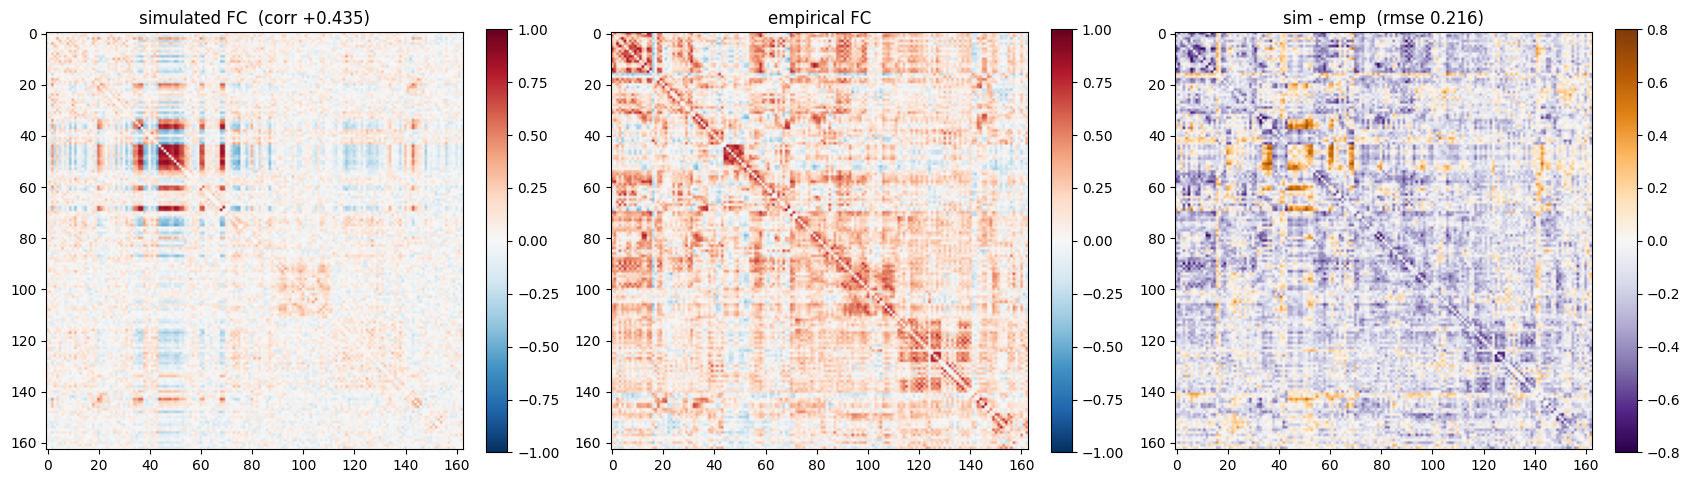

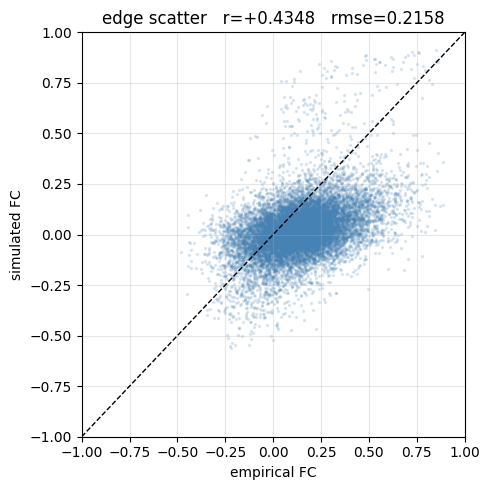

In [8]:
dur = int(cfg.optimizer_bold_window_tr * cfg.bold_repetition_time_ms)
FC_sim = np.asarray(
    compute_simulated_fc(network, bundle, cfg,
                         sim_duration_ms=dur,
                         skip_tr=cfg.optimizer_bold_skip_tr),
    np.float32)

x, y   = FC_emp[iu], FC_sim[iu]
corr   = float(np.corrcoef(x, y)[0, 1])
rmse   = float(np.sqrt(np.mean((y - x) ** 2)))
mt     = sc_bool[iu]
corr_sc = float(np.corrcoef(x[mt], y[mt])[0, 1])

print(f"idx {IDX} ({SUB})   model={MODEL}")
print(f"  corr        {corr:+.4f}")
print(f"  rmse        {rmse:.4f}")
print(f"  corr (SC>0) {corr_sc:+.4f}")
print(f"  c_ei mean   {c_ei.mean():.4f}      mean_S_e {se:.4f}")
if IDX in OPT:
    print(f"  참고: 선형공식 {BASE_LIN.get(IDX, float('nan')):.4f}   "
          f"optimized {OPT[IDX]:.4f}   재현율 {corr/OPT[IDX]*100:.1f}%")

panels = [(FC_sim,          f"simulated FC  (corr {corr:+.3f})", "RdBu_r", (-1, 1)),
          (FC_emp,          "empirical FC",                      "RdBu_r", (-1, 1)),
          (FC_sim - FC_emp, f"sim - emp  (rmse {rmse:.3f})",     "PuOr_r", (-0.8, 0.8))]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, (Mx, ttl, cm, lim) in zip(axes, panels):
    im = ax.imshow(Mx, cmap=cm, vmin=lim[0], vmax=lim[1], aspect="equal")
    ax.set_title(ttl)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x, y, s=2, alpha=0.15, color="steelblue")
ax.plot([-1, 1], [-1, 1], "k--", lw=1)
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
ax.set_xlabel("empirical FC"); ax.set_ylabel("simulated FC")
ax.set_title(f"edge scatter   r={corr:+.4f}   rmse={rmse:.4f}")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()